### Read Me
This jupyter notebook contains following information to reproduce the result of Fig. 4 in Tsuchiyama et al.
1. Define the diffusion equation
2. Import earthquake data
3. Calculate rupture-induced heating per fault
4. Simulate heat distribution through the seismic migration
5. Time series of the max. and mean temperature in the white rectangles in Fig. 4

### 0. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from obspy import UTCDateTime
import matplotlib as mpl
import matplotlib.patches as patches
from math import pi
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.mlab as ml
import matplotlib.animation as animation
from obspy import UTCDateTime
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import datetime
import matplotlib.dates as mdates
mpl.rcParams['pdf.fonttype'] = 42

### 1. Define diffusion equation

In [2]:
def heat2d_fd(dx,kappa,T0):
    """
    HEAT2D_FD function to run a 2D heat equation code in 
    Python using a second order approximation

    Solve using finite difference of second order the diffusion 
    equation for a given initial boundary condition.

    matrix in 2D (nz,nx) with some initial condition. 

    """

#----------------------------------------------------------
    import numpy as np

#----------------------------------------------------------
#  Some initial checks
#----------------------------------------------------------

    
    if (nt < 2):
        print("Error, simulation too short, nt>2")
        return
    nx    = np.size(kappa,0)
    ny    = np.size(kappa,1)
    nx2   = np.size(T0,0)
    ny2   = np.size(T0,1)

    if (nx != nx2 or ny != ny2):
        print("Error, matrix sizes disagree")
        return

#----------------------------------------------------------
#  Coefficients, SECOND
#----------------------------------------------------------
    B1 = -2.0
    B2 = 1.0

#----------------------------------------------------------
# Define dx, dt, matrix sizes, etc
#----------------------------------------------------------

    rmin  = 1.0/4.0  # stability limit
    dt    = rmin*dx**2/np.amax(kappa)
    r2    = (dt/dx**2)*kappa

#    print('dt (days), dx',dt/86400,dx)
#    print(np.shape(kappa),nx,ny)

#----------------------------------------------------------
# Create T(nx,ny,nt)
#----------------------------------------------------------

    T         = np.zeros((nx,ny,2))
    T[:,:,0]  = T0

#--------------------------------------
# Run heat diffusion
#--------------------------------------

    k = 0
    T[1:-1,1:-1,k+1] = ((1 - 4*r2[1:-1,1:-1])*T[1:-1,1:-1,k]
                            + B2*r2[1:-1,1:-1]*(T[2:,1:-1,k] + T[:-2,1:-1,k]
                            +T[1:-1,2:,k]+T[1:-1,:-2,k]))


                               
    # Boundary conditions 
    T[0 , : , k+1]     = T[0 , :,0]    
    T[-1, : , k+1]     = T[-1, :,0]
    T[: , 0 , k+1]     = T[: , 0,0]   
    T[: , -1, k+1]     = T[: ,-1,0]

    return (T[:,:,1], dt)


### 2. Import earthquake catalog with their locations in the modeling domain

In [3]:
catalog=pd.read_csv('hypo_catalog.csv') #catalog used in Fig. 4
catalog['time'] = pd.to_datetime(catalog['time'], utc=True)

### Plot earthquake locations onto the model domain (Fig.4a and b)

In [4]:
# Size of matrices, create matrices
nz = 2000 #unit: m   
nx = 500 #unit: m

#------------------------------------
# Making color map from template ids
#------------------------------------
temp_list = pd.read_csv('catalog_16subtemplates.csv')
cm = mpl.colormaps.get_cmap('coolwarm')
cmap = []; colors=[]
for idx in range(len(temp_list)-1,-1,-1):
    cmap.append(cm(idx/len(temp_list))) #reversed coolwarm

#------------------------------------
# Assigning colors for each event
#------------------------------------
for tempid in catalog['tempid']:
    idx = temp_list[temp_list['tempid']==tempid].index[0]
    colors.append(cmap[idx])
catalog['color']=colors

catalog_reloc=catalog[catalog['reloc']==1] #M>3 events (relocated)
catalog_random=catalog[catalog['reloc']==0] # un-relocated events (random locations)
    

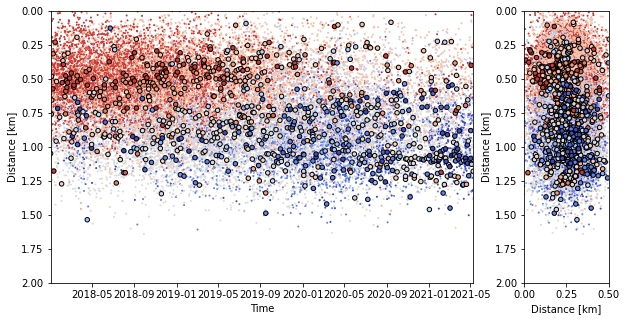

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10, 5),gridspec_kw={'width_ratios': [5, 1]})

ax1.scatter(catalog_random['time'], catalog_random['z'],s=1,c=catalog_random['color'])
ax1.scatter(catalog_reloc['time'],catalog_reloc['z'],s=20,c=catalog_reloc['color'],edgecolor='k')
ax1.set_xlabel('Time'); ax1.set_ylabel('Distance [km]')
ax1.set_ylim([0,2])
ax1.invert_yaxis()
ax1.margins(x=0)

ax2.scatter(catalog_random['x'],catalog_random['z'],s=1,c=catalog_random['color'])
ax2.scatter(catalog_reloc['x'],catalog_reloc['z'],s=20,c=catalog_reloc['color'],edgecolor='k')
ax2.set_xlim([0,0.5]); ax2.set_ylim([0,2])
ax2.set_xlabel('Distance [km]'); ax2.set_ylabel('Distance [km]')
ax2.invert_yaxis()

plt.show()
#plt.savefig('Figure4/figure4a_and_b.pdf')

### 3. Calculate rupture-induced heating

In [6]:
myu = 6.62*10**10       # shear modulus [Pa] from Prieto et al. (2013)
stress_drop = 10*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]
G_slope = 10**8         #slope of intermediate-depth earthquakes in Figure 3 (Prieto et al., 2013)

#--------------------------------------------------------
moment_mag = 0.958*catalog['mag']+0.1 #SGC mag to moment mag
moment = 10.**(1.5*moment_mag+9.1) #Hanks and Kanamori (1979)

radius  = np.cbrt((7.*moment)/(16.*stress_drop)) #Eshelby's circular crack model
area    = np.pi*(radius**2.) # fault area: A = r^2 * pi [m^2]
slip    = stress_drop*(16.*radius)/(7.*myu*np.pi) # slip [m]
#--------------------------------------------------------

C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
density = 3360*10**3       # density of the slab [g/m^3]
G       = G_slope*slip**2  # earthquake fracture energy per unit area
swid    = [0.01,0.003,0.001] # fault width [m]

S_T_array     = np.zeros((len(swid),len(G)))
for i,width in enumerate(swid): 
    S_T_array[i,]  =  G/(C*density*width) # source T increase

### Magnitude vs temperature across three fault widths

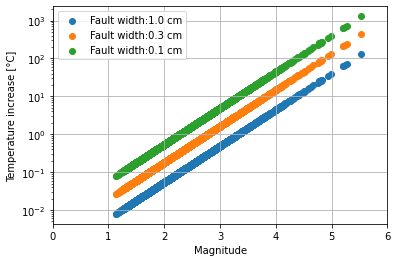

In [7]:
for i in range(S_T_array.shape[0]):
    plt.scatter(catalog['mag'], S_T_array[i,], label='Fault width:{} cm'.format(swid[i]*10**2))
plt.xlim([0,6])
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Temperature increase [°C]')
plt.grid()
plt.legend()

### 4. Simulate heat distribution through seismic migration

(2000, 500)
Initial parameters
dt 4166.67  min
nskip  21
heat routine
Time      83.91 days
Time     185.19 days
Time     332.75 days
Time     353.01 days
Time     387.73 days
Time     460.07 days
Time     520.83 days
Time     587.38 days
Time     645.25 days
Time     665.51 days
Time     792.82 days
Time     824.65 days
19716
19755
19871
Time    1024.31 days
Time    1035.88 days
Time    1145.83 days
Time    1151.62 days
end heat routine


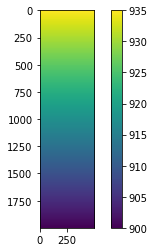

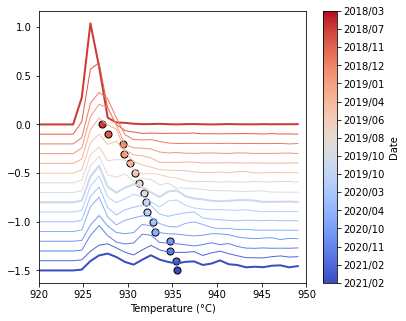

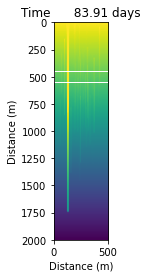

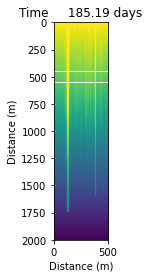

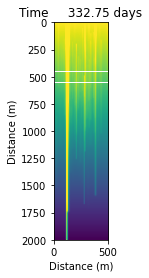

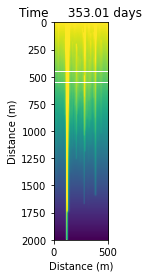

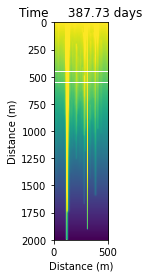

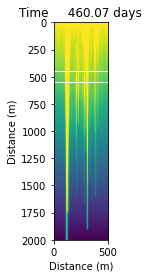

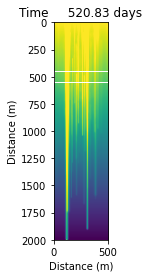

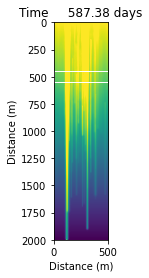

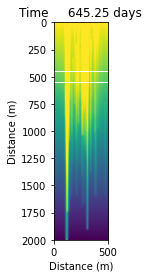

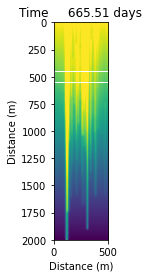

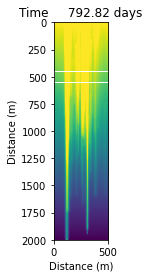

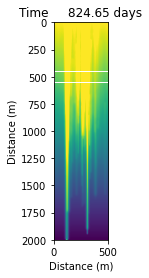

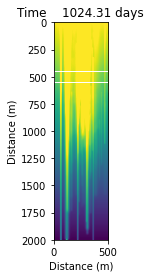

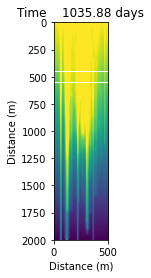

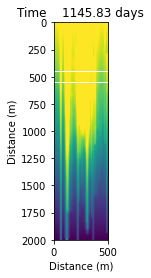

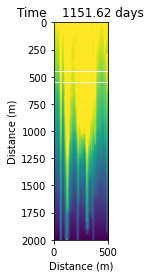

In [8]:
# Sampling in m
dx    = 1     # m

# Source info + Add heat from EQ
Tsrc      = np.zeros((nz,nx))
zmed      = int(nz/2)
xmed      = int(nx/2)

# Diffusivity model (cte diffusion)
kappa = np.ones((nz,nx))*1e-6

#-------------------------------------
# Initial condition
#--------------------------------------

Ttop = 935    #Ttop0 = 300
Tbot = 900    #Tbot0 = 600
Tline = np.linspace(Ttop,Tbot,nz)
mat   = np.tile(Tline, (nx,1))  # Repeats the vector 4 times vertically
T0    = mat.T 
print(np.shape(T0))
T1 = np.copy(T0)

plt.figure(1)
im = plt.imshow(T0)
plt.colorbar(im)

#-------------------------------------------
# Convert time series into model time steps
#-------------------------------------------

time0 = UTCDateTime("2018-01-01T00:00:00")
nt = UTCDateTime(np.max(catalog['time'])) - time0
nt = nt/60 #total time length in days

Ttest,dt   = heat2d_fd(dx,kappa,T0)

nt = int(nt/(dt/60))+1
dsrc = [int(((UTCDateTime(time) - time0)/60)/(dt/60)) for time in catalog['time']]
dsrc_time = [time0 + segment_index * dt for segment_index in dsrc]
dsrc = np.array(dsrc)
radius = np.array(radius)

dsrc_time_dt = [dt.datetime for dt in dsrc_time] 
dsrc_time_dt = np.array(dsrc_time_dt)

r = np.array(catalog['z']) #km
r = dx*r*10**3
rx = np.array(catalog['x']) #km
rx = dx*rx*10**3
    
print('Initial parameters')
print('dt %6.2f  min' %(dt/60))

#-------------------------------------
# Template Index
#-------------------------------------
template_index = []
for i in range(len(temp_list)):
    time = UTCDateTime(temp_list['event_time'].iloc[i])
    template_index.append(int((time - time0) / dt))

#-------------------------------------
# Run heat diffusion
#--------------------------------------

#fig1: time series of average temperature
fig1=plt.figure(100, figsize=(6,5))
ax1 = fig1.add_subplot(111)

dT_center=np.zeros((nt)) #time series of dT in a localized area
dT_center_max=np.zeros((nt)) #time series of the max of dT in a localized area

k = 0
ii = 0 

n_temp=0

nskip = int(np.round(nt/20))
print('nskip ', nskip)
t     = np.arange(nt)
print("heat routine")
for i in range(nt):
    if i in dsrc:
        count = np.sum(dsrc == i) #count the number of events on the i-th day
        count_prev = np.sum(dsrc < i) #count the number of events until the i-th day
        for j in range(count):
            n_event_id = count_prev + j
            S_T = S_T_array[1,n_event_id] #source temperature
            swid = int(radius[n_event_id]) # half width of fault (in samples)
            r_j = int(r[n_event_id])
            rx_j = int(rx[n_event_id])
            if i > 317 and i < 322:
                if S_T > 50:
                    print(n_event_id)
            if abs(rx_j) < nx: #ignore events out of frame
                Tsrc      = np.zeros((nz,nx)) #initializing, otherwise the source information would be pilled up!
                Tsrc[r_j-swid:r_j+swid,rx_j] = 1.0
                if r_j-swid < 0: # avoid ignoring data
                    Tsrc[0:r_j+swid,rx_j] = 1.0
                T0 = T0+Tsrc*S_T   #src is S_T degrees
    
    T1,dt   = heat2d_fd(dx,kappa,T0)
    T0[:,:] = T1[:,:]
    t[i] = t[i]*dt

    dT_center[i]=np.mean(T1[450:550,:])
    dT_center_max[i]=np.max(T1[450:550,:])

    #if (i%nskip==0):
    if i in template_index:
        n_temp=n_temp+1
        fig, ax = plt.subplots(figsize=(6,4))
        im = ax.imshow(T1,vmin=Tbot,vmax=Ttop)
        rect = patches.Rectangle((0, 450),500, 100,linewidth=1,edgecolor='white',facecolor='none')
        ax.add_patch(rect)
        ax.set_xlim([0,nx]); ax.set_ylim([0,nz])
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Distance (m)')
        plt.gca().invert_yaxis()
        ax.set_title('Time %10.2f days' %(t[i]/86400))
        print('Time %10.2f days' %(t[i]/86400))
 
        #T1_zmean=np.mean(T1[:,xmed-50:xmed+50], axis=1)
        plt.savefig('pdf/heatmap_{}.pdf'.format(n_temp))

        data=T1[450:550,:]
        #data=T1[:,xmed-50:xmed+50]
        counts, edges = np.histogram(data, bins=31, range=(920, 950), density=True)
        #counts, edges = np.histogram(data, bins=61, range=(900, 960), density=True)
        if ii in [0,7,15]:
            ax1.plot(edges[:-1], 2*counts-0.1*ii, color=cmap[ii], linewidth=2)
        else:
            ax1.plot(edges[:-1], 2*counts-0.1*ii, color=cmap[ii], linewidth=1)
        ax1.scatter(np.mean(data), -0.1*ii, color=cmap[ii], edgecolor='k', s=50)
        ax1.set_xlabel('Temperature (°C)')
        ax1.set_xlim([920,950])
        #colorbar
        if ii == 0:
            norm = Normalize(vmin=0, vmax=15)
            sm = ScalarMappable(norm=norm, cmap=cm)
            sm.set_array([])
            cbar = fig1.colorbar(sm, ax=ax1, ticks=range(len(temp_list)))
            labels=[UTCDateTime(t).strftime("%Y/%m") for t in temp_list['event_time']][::-1]
            cbar.set_ticklabels(labels)
            cbar.set_label("Date")
        fig1.savefig("ax4_only_full_length.pdf")        
        ii = ii + 1
        
print("end heat routine")

### 5. Plot time series of the max and mean temperature 

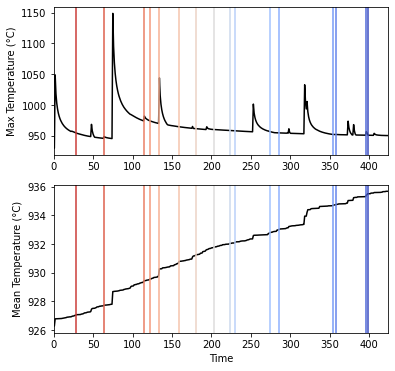

In [9]:
fig=plt.figure(200, figsize=(6,6))
ax1=fig.add_subplot(211)
ax1.plot(np.arange(nt), dT_center_max, c='k')
for i,idx in enumerate(template_index):
    ax1.axvline(x=idx, color=cmap[i])
ax1.set_ylabel('Max Temperature (°C)')
ax.set_ylim([925,945])
ax1.set_xlim([0,nt])

ax2=fig.add_subplot(212)
ax2.plot(np.arange(nt), dT_center, c='k')
for i,idx in enumerate(template_index):
    ax2.axvline(x=idx, color=cmap[i])
ax2.set_ylabel('Mean Temperature (°C)')
ax.set_ylim([925,945])
ax2.set_xlim([0,nt])
ax2.set_xlabel('Time')

plt.show()
#plt.savefig('pdf/temperature_timeseries.pdf')